# Random walks on graphs


<div class="note"><span class="note-t">TL;DR</span>
<p>We turn an eight-node random walk into one <code>PSWAP</code> layer per graph sweep and extend the construction to oriented edges with a directed <code>PJUMP</code> cycle. We then separate deterministic Trotter bias, Monte Carlo noise, and the second-order gain from a Strang sweep.</p>
</div>

In this tutorial, we express a random walk on a graph (probability mass moving along its edges) as a **parametrised stochastic circuit**: one graph node is one **pbit**, each edge is one `PSWAP` gate, and a stack of Trotter layers approximates the graph heat flow.

The graph Laplacian is a sum of edge terms, so the continuous-time walk splits into small two-node updates. A single `PSWAP` is the exact update for one edge, and repeating a layer of `PSWAP` gates approximates the full walk.

We first map one edge to one `PSWAP` gate, which implements the exact two-node Markov kernel (the transition rule for one step of the walk). Then we compose an eight-node graph as one Trotter layer of `PSWAP` gates and watch the distribution diffuse. Finally, we sweep the Trotter resolution to separate Trotter bias from Monte Carlo noise, square the convergence rate with a symmetric Strang sweep, and extend the construction to directed edges with the `PJUMP` gate.

We assume familiarity with the gate set from notebook 01, and the code uses Torx, JAX, NumPy, and NetworkX.



## Setup

The setup cells put the shared `helpers` directory on the import path; `examples/helpers/_graph_diffusion.py` provides the exact heat-flow reference and the sampled product-formula estimates used below.

In [1]:
from pathlib import Path
import sys

import jax
import jax.numpy as jnp
import networkx as nx
import numpy as np

from torx.psc import DiscretePCircuit, PSWAP, SampleSimulator



In [2]:
# Resolve helper imports whether the notebook runs from the root or notebook directory.
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [3]:
from jax.scipy.special import logit
from _notebook_paths import figure_dir
from _graph_diffusion import (
    _edge_swap_probability as shared_edge_swap_probability,
    build_graph_generator,
    reference_heat_flow,
    sample_pswap_product_formula,
    sample_pswap_product_formula_multiseed,
)
import _plots_sampling as P_samp
import _plots_schematics as P_sch
from _notebook_style import (
    apply_notebook_style,
    make_savefig,
)


In [4]:
FIGURE_DIR = figure_dir(ROOT)
apply_notebook_style()
savefig = make_savefig(FIGURE_DIR)

## What the circuit computes

The walk spreads an occupancy distribution $p(t)$ over time, and it obeys the master equation (the rule for how the distribution changes over time) $\dot p = Qp$.

The exact answer is the matrix exponential $p(t) = e^{tQ}p_0$. For a symmetric graph walk the generator (the matrix that drives the time evolution) is minus the graph Laplacian, $Q = -L$, where

$$
L \;=\; \sum_{\{i,j\} \in E} w_{ij}\,(e_i - e_j)(e_i - e_j)^\top, \qquad L\mathbf 1 = 0 .
$$

In the code below, every edge uses the same walk rate `RATE`, so $w_{ij} = \texttt{RATE}$ and $w_{ij}\,\Delta t = \texttt{RATE}\,\Delta t$ is the first-order term of the exact `PSWAP` probability.

The Laplacian is a sum of edge-local terms, so the heat flow $\dot p = -Lp$ splits the same way. That per-edge structure gives a circuit layer with one `PSWAP` per edge:

$$
\underbrace{T}_{\vphantom{\big|}\text{Trotter layer}} \;=\; \prod_{\{i,j\} \in E} \mathrm{PSWAP}_{ij}(p_{ij}), \qquad
\mathrm{PSWAP}_{ij}(p_{ij}) = \mathbb I - \underbrace{p_{ij}}_{\vphantom{\big|}\text{swap prob}}\,(e_i - e_j)(e_i - e_j)^\top .
$$

The product runs one `PSWAP` per edge, each a two-node walk on edge $\{i,j\}$. Its rank-one term $(e_i - e_j)(e_i - e_j)^\top$ is the same edge-local operator that appears in $L$.

Each `PSWAP` is the *exact* edge propagator $e^{\Delta t\,Q_{ij}}$ on its edge; the occupancy form $\mathbb I - p_{ij}(e_i-e_j)(e_i-e_j)^\top$ above is the single-walker map it induces. The circuit is the *ordered* product of these edge propagators, repeated $N$ times:

$$
p(t) \;\approx\; \underbrace{\Big(\textstyle\prod_{\{i,j\}\in E} e^{\Delta t\,Q_{ij}}\Big)^{N}}_{\vphantom{\big|}\text{the circuit}} p_0 \;\xrightarrow[N\to\infty]{}\; \underbrace{e^{-Lt}\,p_0}_{\vphantom{\big|}\text{exact heat flow}}, \qquad \Delta t = t/N .
$$

The edge generators do not commute, so the ordered product equals $e^{-Lt}$ only in the limit; this is the classical Lie-Trotter product formula (Trotter 1959). The first-order expansion of one layer is $\mathbb I - \Delta t\,L$ (one Euler step), which is where the $1/N$ Trotter bias studied below comes from.

The schematic follows one highlighted edge from the graph to its `PSWAP` factor, then tiles the per-edge gates into one Trotter layer $T$; the stacking of layers in time appears later, in the four-node ring circuit figure.

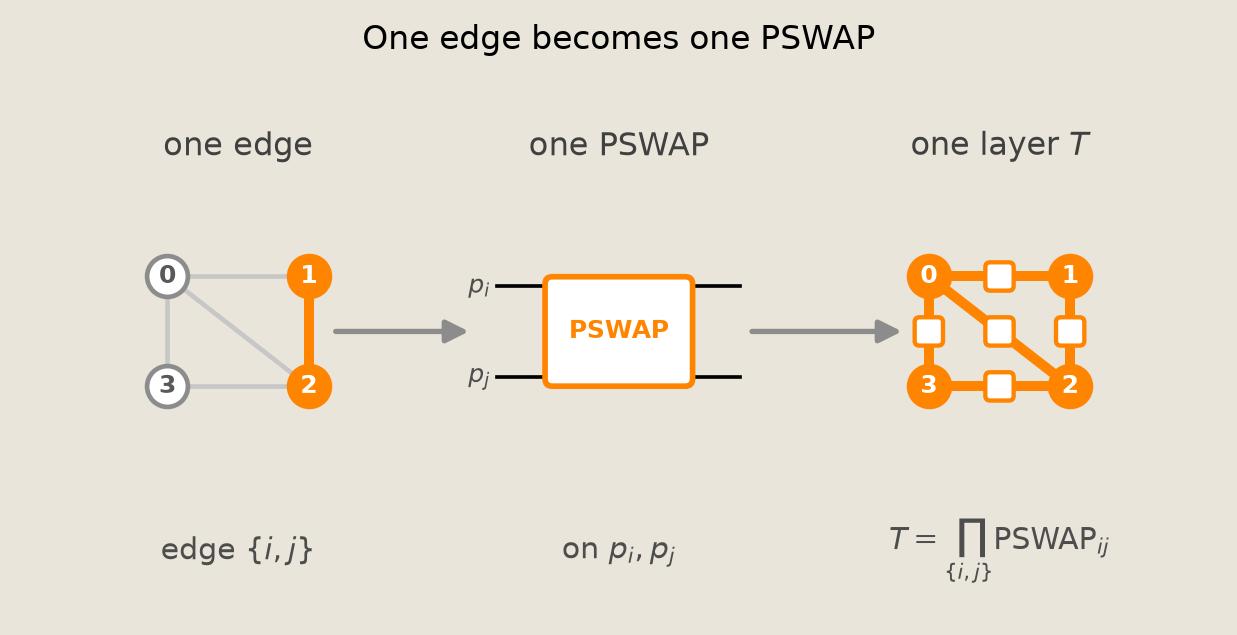

In [5]:
# A tiny toy graph just for the schematic (panel 1); the real 8-node graph
# is built in the "Building the graph" section below. Highlight one edge to carry through the decomposition.
toy_edges = [(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)]
toy_pos = {0: (-0.9, 0.7), 1: (0.9, 0.7), 2: (0.9, -0.7), 3: (-0.9, -0.7)}

fig = P_sch.decomposition_schematic(
    toy_edges=toy_edges,
    toy_pos=toy_pos,
    highlight_edge=(1, 2),
)
savefig(fig, "02_decomposition")

## One edge, one PSWAP gate

The smallest graph has two nodes joined by one edge.

A walker at node 0 stays with probability $1-p$ and moves to node 1 with probability $p$. For a symmetric two-node walk at rate $r$ over a time $\Delta t$:

$$
p \;=\; \tfrac{1}{2}\bigl(1 - e^{-2r\,\Delta t}\bigr).
$$

For the graph examples below, $r$ is the code constant `RATE`, so the first-order term $r\,\Delta t$ is the same $w_{ij}\,\Delta t$ from the Laplacian description.

This is the swap probability fed to `PSWAP`, which is parametrised by a logit (the log-odds of the probability). The wrapper below evaluates it via the shared helper in `examples/helpers/_graph_diffusion.py`. For gate-set details, see [`01_introduction_to_parametrised_stochastic_circuits.ipynb`](01_introduction_to_parametrised_stochastic_circuits.ipynb).

In [6]:
def edge_swap_probability(time, rate):
    """Shared symmetric two-node walk probability for one slice."""
    return shared_edge_swap_probability(rate, time, 1)

These values define the one-edge transition.

In [7]:
RATE = 0.7
DEMO_TIME = 0.8
p_swap = edge_swap_probability(DEMO_TIME, RATE)

The one-edge circuit uses a single `PSWAP` gate on two pbits.

In [8]:
# Gates carry only structure (the two pbit sites); the swap logit lives in
# `thetas`, one entry per gate aligned with `circuit.gates`.
edge_circuit = DiscretePCircuit([PSWAP([0, 1])])
edge_thetas = [jnp.array([logit(p_swap)])]

We draw the circuit to make the two-pbit gate explicit.

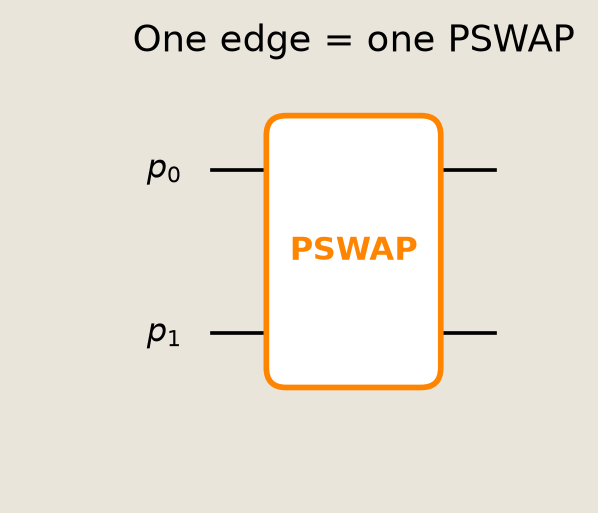

In [9]:
fig = P_sch.draw_pcircuit(
    edge_circuit,
    wire_labels=[r"$p_0$", r"$p_1$"],
    title="One edge = one PSWAP",
)
savefig(fig, "02_edge_circuit")

The simulator estimates the endpoint occupancies, which we compare with the analytic two-node flow.

In [10]:
EDGE_NUM_SAMPLES = 20_000
sim = SampleSimulator(num_samples=EDGE_NUM_SAMPLES)
compiled = sim.build_circuit(edge_circuit, edge_thetas)

# Start the walker at node 0, then read out the two endpoint occupancies.
initial_bits = jnp.array([1, 0], dtype=jnp.int32)
sampled = np.asarray(sim.expval_all(compiled, initial_bits, jax.random.key(0)))
exact_endpoint = np.array([1.0 - p_swap, p_swap])

print(f"swap probability:           {p_swap:.3f}")
print(f"exact occupancies:          {np.round(exact_endpoint, 3).tolist()}")
print(f"Torx sampled occupancies:   {np.round(sampled, 3).tolist()}")

swap probability:           0.337
exact occupancies:          [0.663, 0.337]
Torx sampled occupancies:   [0.6620000004768372, 0.33799999952316284]


The sampled occupancies match the analytic two-node flow, which the next cell asserts within Monte Carlo tolerance.

In [11]:
edge_sample_sigma = 0.5 / np.sqrt(EDGE_NUM_SAMPLES)
assert np.allclose(sampled, exact_endpoint, atol=6 * edge_sample_sigma)

## Building the graph

We build the edge set from an eight-node cycle plus four chords across the middle.

The chords give the walker shortcuts across the ring, so the heat front spreads faster than it would on the cycle alone.

In [12]:
NUM_NODES = 8

cycle_edges = [(i, (i + 1) % NUM_NODES) for i in range(NUM_NODES)]
chord_edges = [(0, 4), (1, 5), (2, 6), (3, 7)]
edges = cycle_edges + chord_edges

We put most of the initial probability mass near node 0.

In [13]:
initial = np.zeros(NUM_NODES)
for node, mass in [(0, 0.70), (1, 0.20), (7, 0.10)]:
    initial[node] = mass
initial /= initial.sum()

In [14]:
graph = nx.Graph()
graph.add_nodes_from(range(NUM_NODES))
graph.add_edges_from(edges)

# Fixed circular layout so every figure uses the same geometry.
angles = np.pi / 2 - 2.0 * np.pi * np.arange(NUM_NODES) / NUM_NODES
pos = {n: np.array([np.cos(a), np.sin(a)]) for n, a in enumerate(angles)}

assert graph.number_of_edges() == len(edges)
assert np.isclose(initial.sum(), 1.0)

## Watching the walk diffuse

The target is the exact heat flow $p(t) = e^{tQ}p_0$ with $Q = -L$. The helpers `build_graph_generator` and `reference_heat_flow` assemble $Q$ and evaluate this matrix exponential.

The first snapshot is the initial state. Later snapshots show mass leaving the hot nodes 0 and 1 along the cycle edges and chord shortcuts, spreading into the rest of the graph as the distribution approaches equilibrium.

We clip the shared color scale to roughly the 98th percentile of the post-initial snapshots, so the later spread stays readable while the $t=0$ peak saturates the warm end.

In [15]:
TOTAL_TIME = 1.4
SNAPSHOT_TIMES = np.array([0.0, 0.35, 0.70, 1.05, 1.40])

generator = build_graph_generator(NUM_NODES, edges, rate=RATE)
snapshots = np.stack(
    [reference_heat_flow(initial, generator, float(t)) for t in SNAPSHOT_TIMES]
)

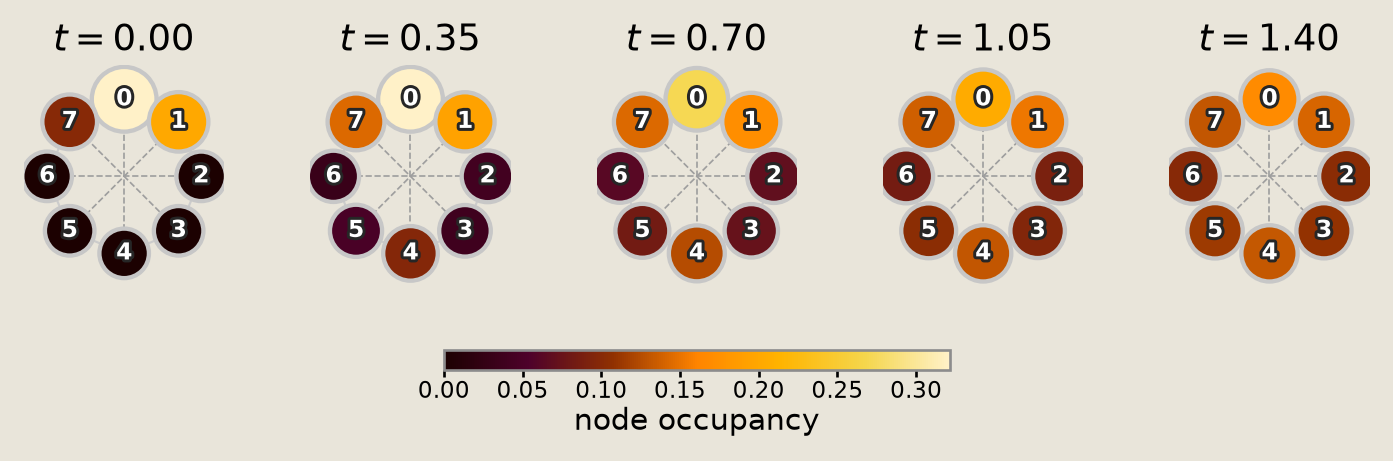

In [16]:
fig = P_sch.diffusion_progression_figure(
    graph,
    pos,
    snapshots,
    SNAPSHOT_TIMES,
    cycle_edges=cycle_edges,
    chord_edges=chord_edges,
)
savefig(fig, "02_diffusion_progression")

The snapshots show probability mass spreading through both the cycle edges and the chord shortcuts.

## Building the Torx circuit

For a Trotter resolution of $m$ steps, each layer applies one `PSWAP` per edge with the swap probability for the slice time $\Delta t = t/m$.

The `DiscretePCircuit` constructor with `reps=m` repeats the whole layer $m$ times, which is the product $T^m \approx e^{tQ}p_0$ from the heat-flow construction above.

In [17]:
STEPS = 16
dt = TOTAL_TIME / STEPS
p_per_layer = edge_swap_probability(dt, RATE)

In [18]:
pswap_layer = [PSWAP([int(i), int(j)]) for i, j in edges]
layer_thetas = [jnp.array([logit(p_per_layer)]) for _ in edges]
preview = DiscretePCircuit(pswap_layer, reps=STEPS)

print(f"{len(preview.gates)} PSWAP gates per layer  x  {preview.reps} layers")
print(f"swap probability per edge per slice: {p_per_layer:.4f}")

12 PSWAP gates per layer  x  16 layers
swap probability per edge per slice: 0.0576


A four-node ring shows the repeated-layer pattern compactly.

In [19]:
ring4 = [(0, 1), (1, 2), (2, 3), (3, 0)]
ring_layer = [PSWAP([int(i), int(j)]) for i, j in ring4]
layer_circuit = DiscretePCircuit(ring_layer, reps=8)

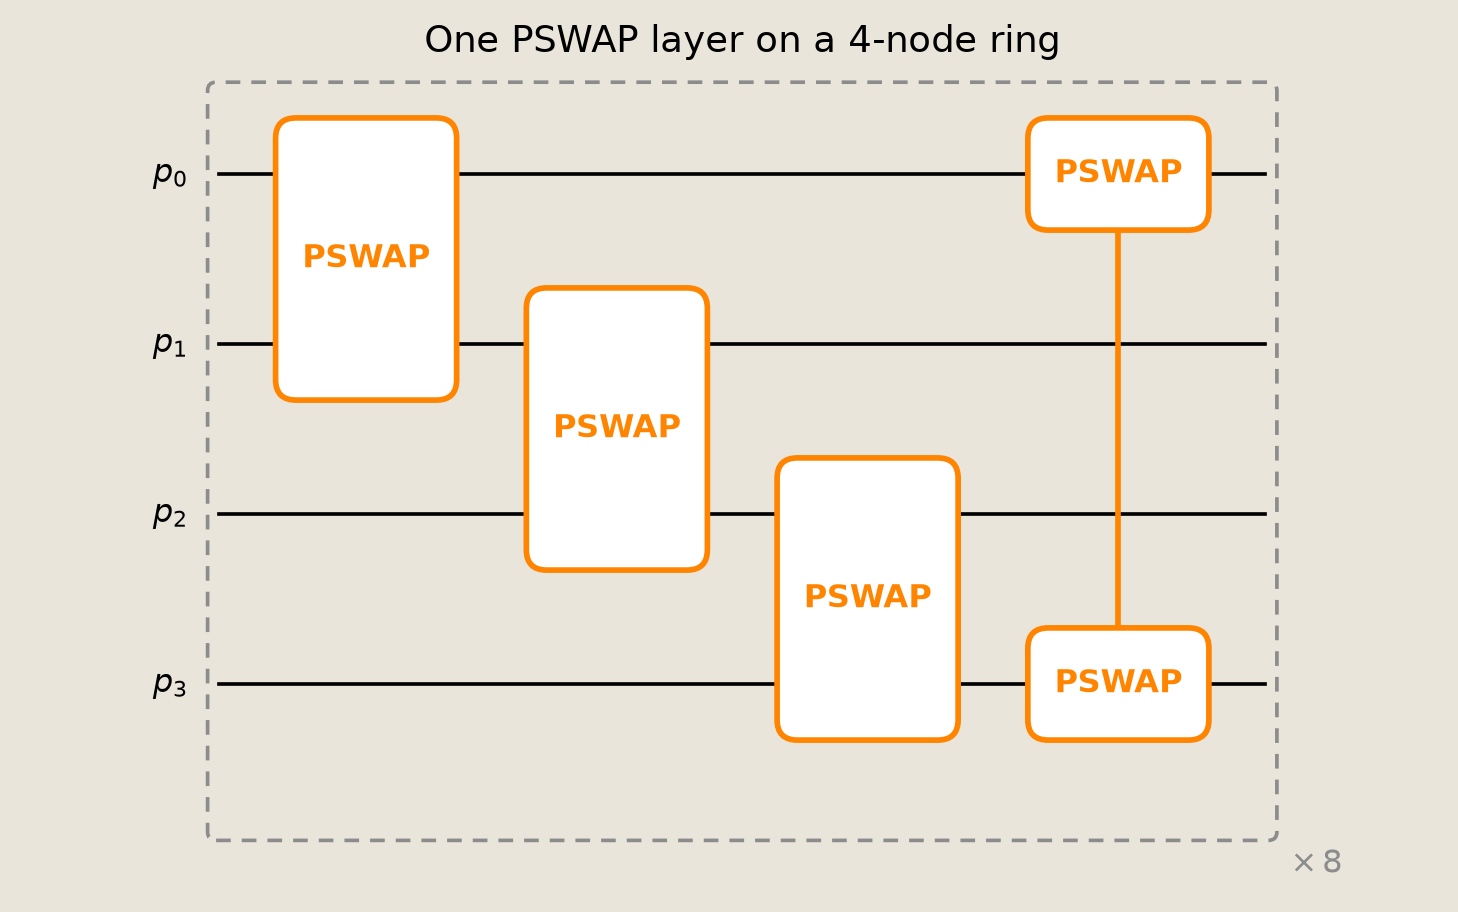

In [20]:
fig = P_sch.draw_pcircuit(
    layer_circuit,
    wire_labels=[rf"$p_{i}$" for i in range(4)],
    title="One PSWAP layer on a 4-node ring",
    reps=layer_circuit.reps,
)
savefig(fig, "02_layer_circuit")

Sampling reads out where a single walker ends up. For a spread-out start, the helper `sample_pswap_product_formula` runs the circuit once per occupied source node and recombines the occupancies by the initial weights, using the linearity of heat flow in $p_0$.

## Coarse and fine checks

We run the same edge layer at a coarse $m=2$ and a finer $m=32$, changing only the resolution: `reps` and the per-slice swap probability that goes with it. The exact $e^{tQ}p_0$ is the reference, and the printed errors compare both estimates.

In [21]:
COARSE_STEPS = 2
FINE_STEPS = 32
NUM_SAMPLES = 12_000

exact = reference_heat_flow(initial, generator, TOTAL_TIME)

In [22]:
def run_circuit(initial, edges, *, steps, total_time, rate, num_samples, seed):
    """Estimate the first-order ordered product formula with the shared sampler."""
    p = edge_swap_probability(total_time / steps, rate)
    return sample_pswap_product_formula(
        initial,
        edges,
        reps=int(steps),
        swap_probability=p,
        num_samples=num_samples,
        seed=seed,
    )

In [23]:
coarse = run_circuit(
    initial,
    edges,
    steps=COARSE_STEPS,
    total_time=TOTAL_TIME,
    rate=RATE,
    num_samples=NUM_SAMPLES,
    seed=1,
)
fine = run_circuit(
    initial,
    edges,
    steps=FINE_STEPS,
    total_time=TOTAL_TIME,
    rate=RATE,
    num_samples=NUM_SAMPLES,
    seed=2,
)

In [24]:
err_coarse = float(np.linalg.norm(coarse - exact))
err_fine = float(np.linalg.norm(fine - exact))

print(f"coarse (m={COARSE_STEPS:>2}) L2 error: {err_coarse:.3f}")
print(f"fine   (m={FINE_STEPS:>2}) L2 error: {err_fine:.3f}")

coarse (m= 2) L2 error: 0.027
fine   (m=32) L2 error: 0.009


Both estimates conserve probability, and the finer run is closer to exact.

In [25]:
mass_atol = 2 * 0.5 / np.sqrt(NUM_SAMPLES)
assert np.isclose(coarse.sum(), 1.0, atol=mass_atol)
assert np.isclose(fine.sum(), 1.0, atol=mass_atol)
assert err_fine < err_coarse

## Trotter convergence

Two error sources appear, and they behave differently.

- **Trotter bias** is the gap between the product formula and exact $e^{tQ}p_0$. First-order Trotter shrinks it as $1/m$: slope $-1$ on a log-log plot.
- **Monte Carlo noise** is the gap between the sampled estimate and the deterministic Trotter mean. By the central limit theorem its scale is $O(1/\sqrt{N})$ in the sample count. It depends on the terminal probabilities, which vary with $m$, but is roughly flat here once the terminal distribution has stabilized.

The deterministic product formula, computed as an exact matrix product per edge, measures pure bias. The sampled Torx estimate uses 12k samples per source across four seeds. The band is the sample standard deviation of those four seeds, so it is an indicative spread rather than a tight confidence interval.

In [26]:
STEPS_SWEEP = [1, 2, 4, 8, 16, 32, 64]
NUM_SEEDS = 4

The deterministic product formula gives the pure-bias baseline, and we compute it exactly per edge.

In [27]:
def deterministic_trotter_step(occupancy, edge_list, swap_prob):
    """One deterministic edge-product-formula layer on a probability vector."""
    out = occupancy.copy()
    for i, j in edge_list:
        a, b = out[i], out[j]
        out[i] = (1.0 - swap_prob) * a + swap_prob * b
        out[j] = swap_prob * a + (1.0 - swap_prob) * b
    return out




In [28]:
def deterministic_trotter(p0, edge_list, *, m, total_time, rate):
    """Deterministic m-step product formula, no sampling."""
    swap_prob = edge_swap_probability(total_time / m, rate)
    # the edge update is linear, so it applies straight to p0 (no per-source split)
    p = np.asarray(p0, dtype=float).copy()
    for _ in range(m):
        p = deterministic_trotter_step(p, edge_list, swap_prob)
    return p




In [29]:
def sweep_trotter_errors(
    initial,
    edges,
    exact,
    *,
    steps,
    total_time,
    rate,
    num_samples,
    num_seeds,
):
    """Return deterministic and per-seed sampled Trotter errors for each resolution in `steps`."""
    det_errors = np.zeros(len(steps))
    for i, m in enumerate(steps):
        det = deterministic_trotter(
            initial, edges, m=m, total_time=total_time, rate=rate
        )
        det_errors[i] = float(np.linalg.norm(det - exact))

    sampled_errors = np.zeros((len(steps), num_seeds))
    for i, m in enumerate(steps):
        # compile once per resolution, then draw all seeds through it
        p = edge_swap_probability(total_time / m, rate)
        approx_per_seed = sample_pswap_product_formula_multiseed(
            initial,
            edges,
            reps=int(m),
            swap_probability=p,
            num_samples=num_samples,
            seeds=[100 + 7 * m + k for k in range(num_seeds)],
        )
        sampled_errors[i] = np.linalg.norm(approx_per_seed - exact, axis=1)
    return det_errors, sampled_errors

In [30]:
det_errors, sampled_errors = sweep_trotter_errors(
    initial,
    edges,
    exact,
    steps=STEPS_SWEEP,
    total_time=TOTAL_TIME,
    rate=RATE,
    num_samples=NUM_SAMPLES,
    num_seeds=NUM_SEEDS,
)

In [31]:
steps_arr = np.asarray(STEPS_SWEEP)
sam_mean = sampled_errors.mean(axis=1)
sam_std = sampled_errors.std(axis=1, ddof=1)

The assertions capture the expected pattern: bias falls, the coarse sampled error matches the deterministic one, and the finest sampled error sits above the deterministic floor.

In [32]:
# Pure Trotter bias drops monotonically; the sampled curve plateaus at the MC floor.
mc_match_atol = 4 * 0.5 / np.sqrt(NUM_SAMPLES)
assert np.all(np.diff(det_errors) < 0)
assert abs(sam_mean[0] - det_errors[0]) < mc_match_atol
assert sam_mean[-1] > det_errors[-1]

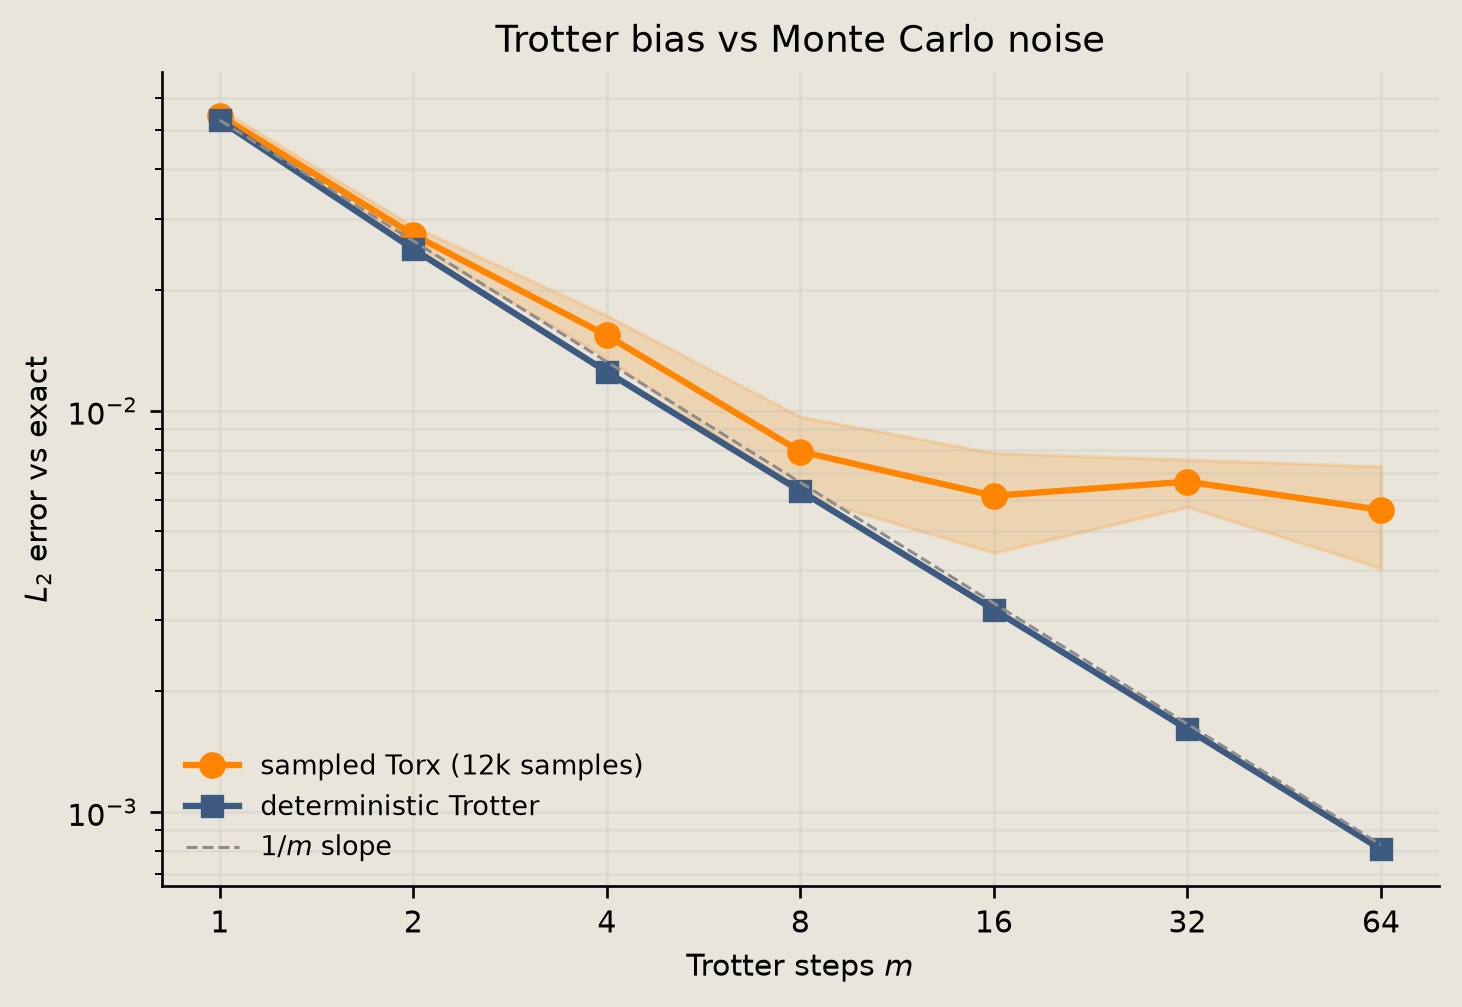

In [33]:
fig = P_samp.trotter_error_figure(
    steps_arr,
    det_errors,
    sam_mean,
    sam_std,
    num_samples=NUM_SAMPLES,
)
savefig(fig, "02_trotter_error")

At small $m$ the sampled and deterministic curves sit on top of each other, both following the $1/m$ Trotter slope. They separate once the Trotter bias drops below the Monte Carlo floor: the deterministic bias keeps falling as $1/m$, but the sampled error flattens at its $O(1/\sqrt{N})$ noise level.

## Second-order splitting

Each `PSWAP` is the exact edge propagator $e^{Q_{ij}\Delta t}$, so a single edge carries no bias. The $1/m$ error above comes from ordering: the edge generators do not commute, so applying them one after another reproduces $e^{\sum_{ij} Q_{ij}\,\Delta t}$ only to first order in $\Delta t$.

A symmetric sweep removes the leading piece of that error. Run the edges forward for a half step and then in reverse for a half step, and the layer becomes its own mirror image, which cancels the leading $O(\Delta t^2)$ local splitting error from the non-commuting edge updates.

This is the classical **Strang splitting** (Strang 1968), the second-order case of the general higher-order product formulas (Suzuki 1976). The cancelled local term leaves a global bias that falls as $1/m^2$.

One Strang layer applies the same edge gates forward and then backward, each for half the slice time.

In [34]:
def deterministic_strang_step(occupancy, edge_list, reverse_edges, half_swap):
    """One symmetric layer: a forward edge sweep, then a reverse sweep, each a half step."""
    out = deterministic_trotter_step(occupancy, edge_list, half_swap)
    return deterministic_trotter_step(out, reverse_edges, half_swap)




In [35]:
def deterministic_strang(p0, edge_list, *, m, total_time, rate):
    """Deterministic m-step second-order product formula."""
    half_swap = edge_swap_probability(total_time / m / 2, rate)
    reverse_edges = list(reversed(edge_list))
    # linear update applies straight to p0; reverse list built once, not per step
    p = np.asarray(p0, dtype=float).copy()
    for _ in range(m):
        p = deterministic_strang_step(p, edge_list, reverse_edges, half_swap)
    return p




In [36]:
strang_errors = np.array(
    [
        np.linalg.norm(
            deterministic_strang(initial, edges, m=m, total_time=TOTAL_TIME, rate=RATE)
            - exact
        )
        for m in STEPS_SWEEP
    ]
)

The same scheme runs in Torx: a Strang layer is the forward edge list followed by its reverse, each gate at the half-step probability. We sample it once to confirm the circuit tracks the exact flow.

In [37]:
def run_strang_circuit(initial, edges, *, steps, total_time, rate, num_samples, seed):
    """Sampled second-order layer: forward edges then reversed, each a half step."""
    half_p = edge_swap_probability(total_time / steps / 2, rate)
    forward_edges = [(int(i), int(j)) for i, j in edges]
    strang_edges = forward_edges + list(reversed(forward_edges))
    return sample_pswap_product_formula(
        initial,
        strang_edges,
        reps=int(steps),
        swap_probability=half_p,
        num_samples=num_samples,
        seed=seed,
    )




In [38]:
strang_sampled = run_strang_circuit(
    initial,
    edges,
    steps=FINE_STEPS,
    total_time=TOTAL_TIME,
    rate=RATE,
    num_samples=NUM_SAMPLES,
    seed=7,
)
strang_sampled_err = float(np.linalg.norm(strang_sampled - exact))
print(f"Strang Torx circuit vs exact (m={FINE_STEPS}): L2 = {strang_sampled_err:.4f}")
# the sampled Strang circuit should track exact within the MC floor plus the tiny bias
strang_mc_tol = 6 * 0.5 / np.sqrt(NUM_SAMPLES)
assert strang_sampled_err < strang_errors[-1] + strang_mc_tol

Strang Torx circuit vs exact (m=32): L2 = 0.0059


We fit slopes to the deterministic curves to confirm the order: first-order decay sits near $1/m$, while Strang sits near $1/m^2$.

In [39]:
lie_slope = np.polyfit(np.log(steps_arr[2:]), np.log(det_errors[2:]), 1)[0]
strang_slope = np.polyfit(np.log(steps_arr[2:]), np.log(strang_errors[2:]), 1)[0]
print(f"first-order slope {lie_slope:.2f}   Strang slope {strang_slope:.2f}")

EXPECTED_LIE_SLOPE = -1.0
EXPECTED_STRANG_SLOPE = -2.0
SLOPE_FIT_TOLERANCE = 0.3
assert (
    strang_errors[-1] < det_errors[-1]
), "Strang should be more accurate at the finest resolution"
assert (
    abs(lie_slope - EXPECTED_LIE_SLOPE) < SLOPE_FIT_TOLERANCE
), "first-order bias should fall close to 1/m"
assert (
    abs(strang_slope - EXPECTED_STRANG_SLOPE) < SLOPE_FIT_TOLERANCE
), "Strang bias should fall close to 1/m^2"

first-order slope -0.99   Strang slope -2.00


We overlay the two bias curves to show the order improvement directly.

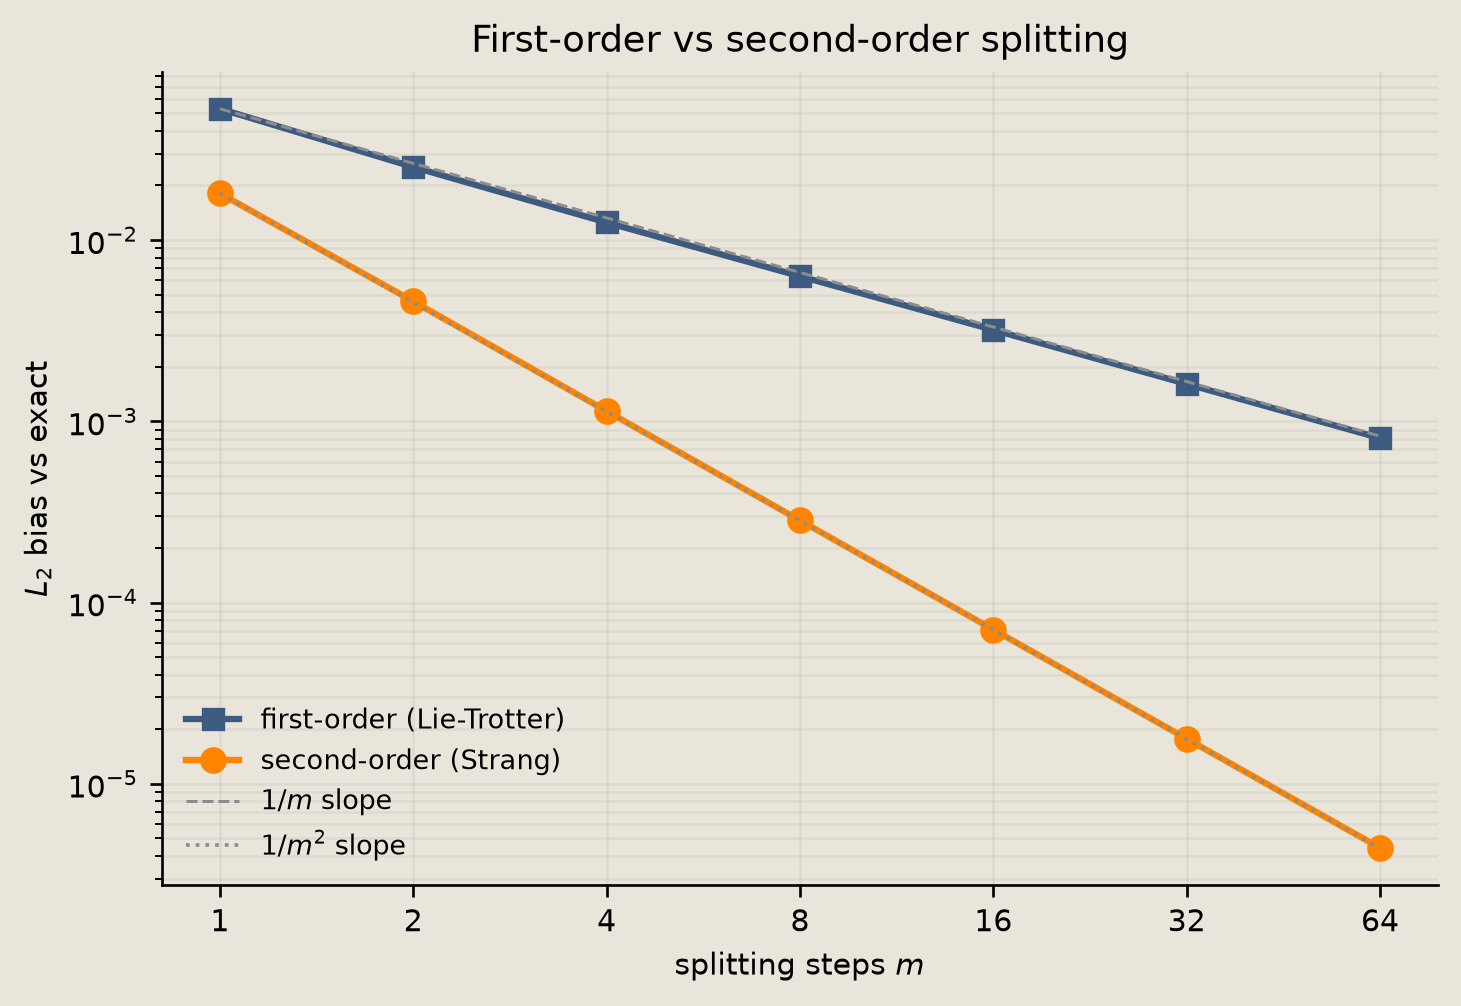

In [40]:
fig = P_samp.splitting_order_figure(steps_arr, det_errors, strang_errors)
savefig(fig, "02_splitting_order")

Reordering the same edge gates into a symmetric sweep turns the $1/m$ bias into a $1/m^2$ bias, and the Torx circuit expresses the higher-order scheme directly.

The cost is one extra edge sweep per step, a constant factor that pays off whenever Trotter bias dominates the target error.

## Directed transport: the PJUMP gate

The `PSWAP` edge above is symmetric: probability flows both ways along an edge. Its directed counterpart is the `PJUMP` gate, which moves a token along an *oriented* edge $a \to b$ at rate $r$. Over a slice $\Delta t$ it sends the token from $a$ to $b$ with probability $p = 1 - e^{-r\,\Delta t}$, but only when $a$ is occupied and $b$ is empty ($a = 1$, $b = 0$). Otherwise it does nothing.

Like `PSWAP`, the gate is parametrised by the logit $\theta = \log\!\big(p / (1 - p)\big)$, and the same Trotter-layer machinery carries over: one `PJUMP` per directed edge is a single layer, and `DiscretePCircuit(gates, reps=m)` repeats it to cover $[0, t]$. The only change from the rest of this tutorial is that the graph is now directed.

In [41]:
from torx.psc import PJUMP

In [42]:
# A short directed cycle: each node has exactly one out-edge, with two rates.
FAST, SLOW = 0.9, 0.4
n_nodes = 5
directed_edges = [
    (0, 1, FAST),
    (1, 2, FAST),
    (2, 3, SLOW),
    (3, 4, FAST),
    (4, 0, SLOW),
]




In [43]:
def pjump_probability(time, rate):
    """Directed-edge jump probability over a slice; the token enters only an empty node."""
    return 1.0 - np.exp(-rate * time)




In [44]:
# Single-particle generator Q: a token at src leaves to dst at the edge rate.
Q = np.zeros((n_nodes, n_nodes))
for src, dst, rate in directed_edges:
    Q[dst, src] += rate
    Q[src, src] -= rate



In [45]:
# One walker starts on node 0.
initial_bits = jnp.zeros(n_nodes, dtype=jnp.int32).at[0].set(1)
p0 = np.zeros(n_nodes)
p0[0] = 1.0
print(f"{n_nodes}-node directed cycle, {len(directed_edges)} directed edges, one walker on node 0")

5-node directed cycle, 5 directed edges, one walker on node 0


We Trotterize with one `PJUMP` per directed edge and compare the sampled occupancy against the exact single-particle reference $e^{Q t} p_0$, sampling snapshot circuits at a few rep counts.

In [46]:
def single_particle_occupancy(Q, p0, times):
    """Exact occupancy e^(Q t) p0 for the small real directed generator."""
    vals, vecs = np.linalg.eig(Q)
    coeff = np.linalg.solve(vecs, p0)
    return np.stack([(vecs @ (np.exp(vals * t) * coeff)).real for t in times])




In [47]:
T = 6.0
N = 300
dt = T / N
times = np.linspace(0.0, T, N + 1)
snapshot_reps = np.arange(60, N + 1, 60, dtype=int)
snapshot_times = snapshot_reps * dt

exact_occ = single_particle_occupancy(Q, p0, times)



In [48]:
gates = [PJUMP([int(src), int(dst)]) for src, dst, rate in directed_edges]
thetas = [jnp.array([logit(pjump_probability(dt, rate))]) for src, dst, rate in directed_edges]
sim = SampleSimulator(num_samples=20_000)
keys = jax.random.split(jax.random.key(0), len(snapshot_reps))
torx_occ = np.stack([
    np.asarray(sim.expval_all(sim.build_circuit(DiscretePCircuit(gates, reps=int(reps)), thetas), initial_bits, key))
    for reps, key in zip(snapshot_reps, keys, strict=True)
])



In [49]:
err = float(np.max(np.abs(torx_occ - exact_occ[snapshot_reps])))
print(f"sampled {len(snapshot_reps)} snapshot circuits at reps {snapshot_reps.tolist()}")
print(f"max |Torx - exact| occupancy: {err:.4f}")
assert err < 0.05
assert np.allclose(torx_occ.sum(axis=1), 1.0, atol=5e-3)

sampled 5 snapshot circuits at reps [60, 120, 180, 240, 300]
max |Torx - exact| occupancy: 0.0074


The sampled occupancies track the exact directed flow at every snapshot; the figure below overlays them.

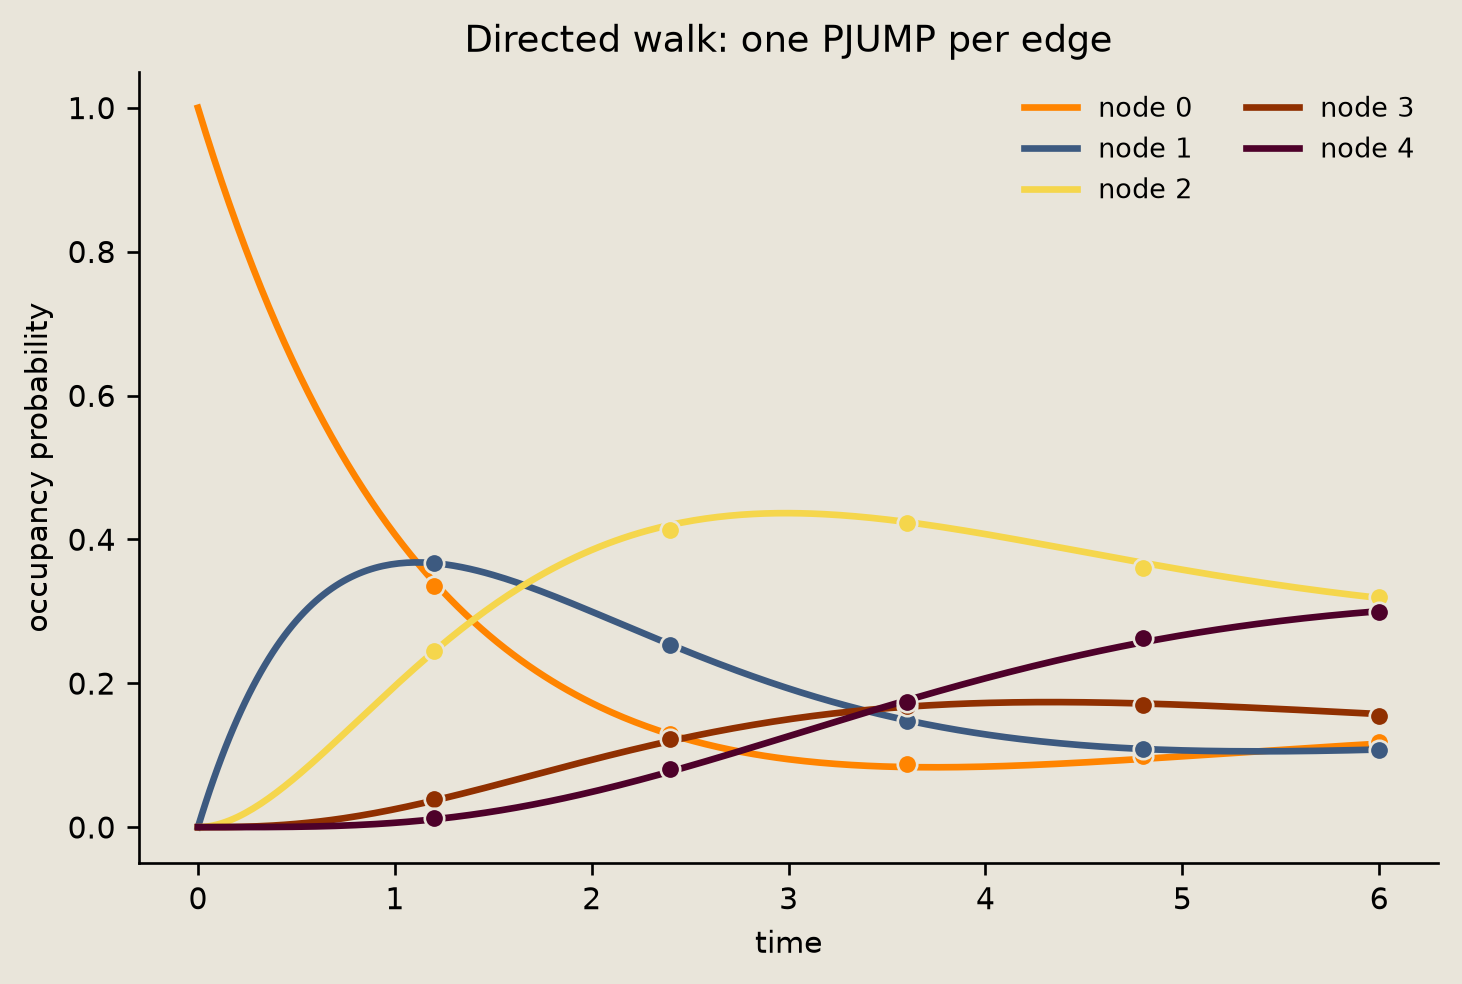

In [50]:
import matplotlib.pyplot as plt
from _notebook_style import FIGURE_BG

fig, ax = plt.subplots(figsize=(6.2, 4.2))
for node in range(n_nodes):
    line, = ax.plot(times, exact_occ[:, node], lw=2.0, label=f"node {node}")
    ax.scatter(
        snapshot_times, torx_occ[:, node], color=line.get_color(),
        s=34, edgecolor=FIGURE_BG, linewidth=0.8, zorder=5,
    )
ax.set_xlabel("time")
ax.set_ylabel("occupancy probability")
ax.set_title("Directed walk: one PJUMP per edge")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper right", frameon=False, ncol=2)
fig.tight_layout()
savefig(fig, "02_directed_transport")

The dots track the exact directed flow, just as the `PSWAP` walk tracked the heat flow earlier. With a single walker the destination node is always empty, so the jumps are an ordinary directed random walk. Add more walkers and the empty-target condition becomes binding: a token cannot hop onto an occupied node, so the walkers exclude one another. That turns the graph into an **exclusion process**: the directed, multi-walker analogue of the symmetric walk studied in this tutorial.

## Conclusion

In this tutorial, we represented a continuous-time random walk on a graph as a stack of per-edge `PSWAP` gates, one pbit per node, and checked it against the exact heat flow.

- Each edge becomes one `PSWAP` gate, and the `DiscretePCircuit` constructor with `reps=m` repeats that layer to cover the time interval.
- The `expval_all` method of `SampleSimulator` reads out node occupancies, recovering the spreading heat front across the eight-node graph.
- Refining the Trotter resolution drives the deterministic product formula toward the exact $e^{tQ}p_0$, with the bias falling as $1/m$.
- Reordering the same edge gates into a symmetric Strang sweep squares the convergence rate, dropping the bias as $1/m^2$.
- The directed `PJUMP` gate reuses the same layer construction on oriented edges, and the sampled walk tracks the exact directed flow $e^{Qt}p_0$.
- The same Laplacian-splits-per-edge pattern carries over to a mesh in [`03_bunny_graph_diffusion.ipynb`](03_bunny_graph_diffusion.ipynb).

## References

1. Strang, G. 1968. [*On the construction and comparison of difference schemes*](https://doi.org/10.1137/0705041). SIAM J. Numer. Anal. 5(3), 506-517. The symmetric second-order splitting used in the second-order section.
2. Trotter, H.F. 1959. [*On the product of semi-groups of operators*](https://www.ams.org/journals/proc/1959-010-04/S0002-9939-1959-0108732-6/). Proc. Amer. Math. Soc. 10(4), 545-551. The first-order product formula underlying the per-edge Trotter layer.
3. Suzuki, M. 1976. [*Generalized Trotter's formula and systematic approximants of exponential operators…*](https://link.springer.com/article/10.1007/BF01609348). Commun. Math. Phys. 51(2), 183-190. The generalized higher-order product formulas that the symmetric Strang sweep is the second-order case of.

